In [19]:
import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
import dnnlib.util_v4 as util
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from plot_neural import *
from plot_sim_results import * 

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)

# 1. Read Data

In [2]:
folder_data = 'data/mc_maze2'
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
data_raw = dataset_samples['samples']
dset_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))

In [3]:
# corresponding meta data
train_meta = np.load(folder_data + "/meta_train.npy", allow_pickle=True).tolist()
trial_idx_use = np.array(train_meta['trial_info']['trial_version']) == 0
np.sum(trial_idx_use)

592

# 2. Take a look of behavior data

In [4]:
trial_type_use = np.array(train_meta['trial_info']['trial_type'])[trial_idx_use]
indices = np.where(trial_idx_use)[0]

target_pos_sel = [train_meta['trial_info']['target_pos'][idx] for idx in indices]
target_pos_sel = np.array(target_pos_sel).squeeze(1).astype(np.float32)

hand_pos_sel = [train_meta['behavior']['hand_pos'][idx] for idx in indices]
cursor_pos_sel = [train_meta['behavior']['cursor_pos'][idx] for idx in indices]
eye_pos_sel = [train_meta['behavior']['eye_pos'][idx] for idx in indices]

In [5]:
# np.save(folder_data + "/cov_static_samples.npy", target_pos_sel)

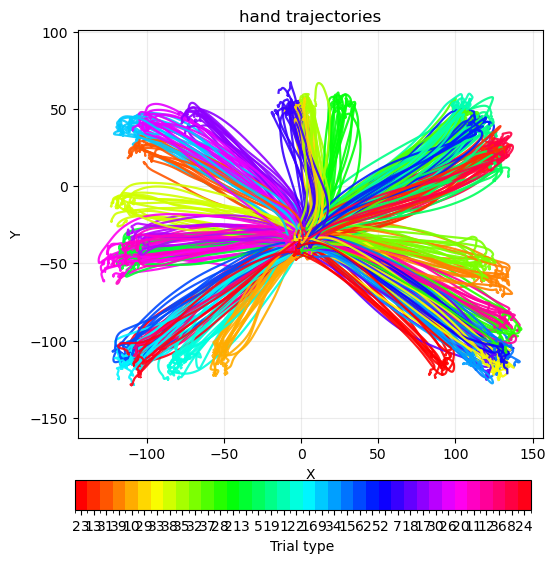

In [6]:
plot_2d_hand_trajectories(hand_pos_sel,
                          trial_indices=None,
                          trial_type_use=trial_type_use,
                          title = "hand trajectories")

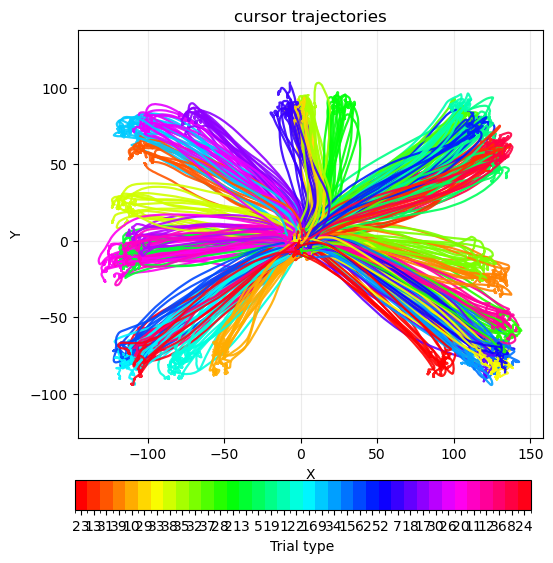

In [7]:
plot_2d_hand_trajectories(cursor_pos_sel,
                          trial_indices=None,
                          trial_type_use=trial_type_use,
                          title = "cursor trajectories")

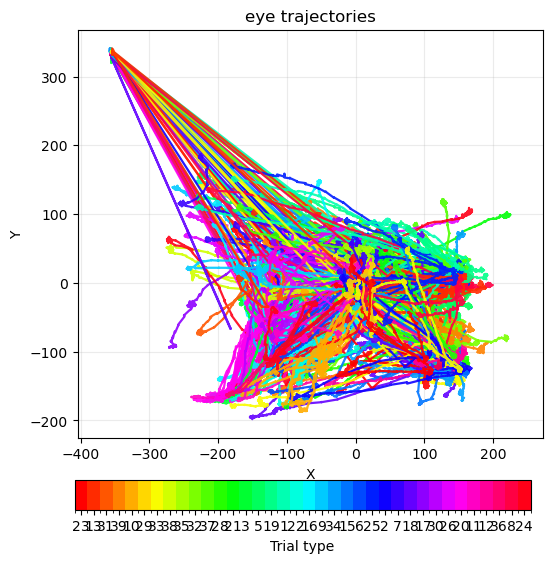

In [8]:
plot_2d_hand_trajectories(eye_pos_sel,
                          trial_indices=None,
                          trial_type_use=trial_type_use,
                          title = "eye trajectories")

Text(0.5, 1.0, 'target position')

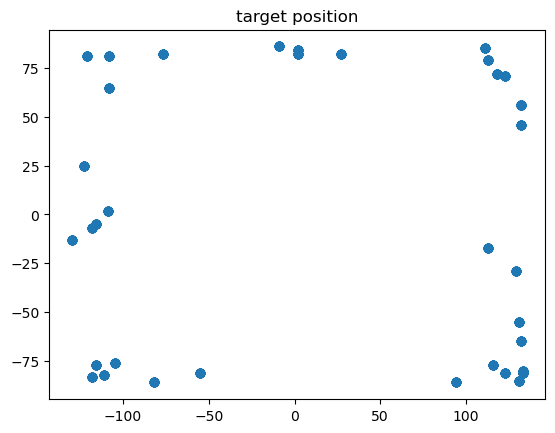

In [9]:
plt.scatter(target_pos_sel[:,0], target_pos_sel[:,1]);
plt.title('target position')

Seems given the target position, the trial to trial variation is small. Let's condition on the position?

# 3. New results

1. latent dimension = 3
2. lag = 5
3. covariate = target location

In [70]:
dt = 0.001
# folder_data = 'out/z_scored/maze/dim3_lag5/data'
# folder = 'out/z_scored/maze/dim3_lag5/00008-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
# pkl_path = folder + '/network-snapshot-260915.pkl'
folder_data = 'out/z_scored/maze/dim3_lag5_v2/data'
folder = 'out/z_scored/maze/dim3_lag5_v2/00000-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-451584.pkl'
dim_preserve = 3

## 3.1 Read Data & Model

In [65]:
dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
lagRead_samples = np.load(folder_data + "/lag_cov_list.npz", allow_pickle=True)
cov_static_all = np.load(folder_data + "/cov_static_new.npz", allow_pickle=True)

In [66]:
data_raw = dataset_samples['samples']
lag_raw = lagRead_samples['samples']
cov_static_raw = cov_static_all['samples']

dset_samples = []
lag_samples = []
covStat_samples = []
for ii in range(len(data_raw)):
    dset_samples.append(np.asarray(data_raw[ii], dtype=np.float64))
    lag_samples.append(np.asarray(lag_raw[ii], dtype=np.float64))
    covStat_samples.append(np.asarray(cov_static_raw[ii][:, 0:(cov_static_raw[ii].shape[1] - lag_raw[ii].shape[1])], dtype=np.float64))

In [67]:
lag = lag_samples[0].shape[1] // dset_samples[0].shape[1] - 1
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [68]:
# # version 1: global clamp (results are similar)
# min_value = min(np.min(arr) for arr in dset_samples)
# max_value = max(np.max(arr) for arr in dset_samples)
# clamp_range = np.array([min_value, max_value]) # give some space

# version 2: clamp dim-by-dim (results are similar)
padded_arrays = [np.pad(arr, ((0, T_max - arr.shape[0]), (0, 0)),
                        mode='constant', constant_values=np.nan) 
                 for arr in dset_samples]
stacked = np.stack(padded_arrays, axis=0)  # Shape [n_trial, T_max, dim]

min_vals = np.nanmin(stacked, axis=(0, 1))  # Shape [dim]
max_vals = np.nanmax(stacked, axis=(0, 1))  # Shape [dim]

clamp_range = np.stack([min_vals, max_vals], axis=1)  # Shape [dim, 2]
clamp_range[:,0] = clamp_range[:,0] - 2
clamp_range[:,1] = clamp_range[:,1] + 2

In [71]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

## 3.2 generated trajectories

### data space (tau = 1.0)

In [72]:
traj_sim_tau1, lag_cov_list = generate_traj_cov(dyn_net.to(device), dset_samples,
                                                n_step = T_max, tau = 1.0,
                                                lag_samples = lag_samples,
                                                device = device, lag = lag,
                                                include_x0_tau = False,
                                                covStat_samples = covStat_samples,
                                                oracle = False, lag_cov_list_pre = None,
                                                clamp_range = clamp_range)

100%|███████████████████████████████████████| 3701/3701 [02:47<00:00, 22.04it/s]


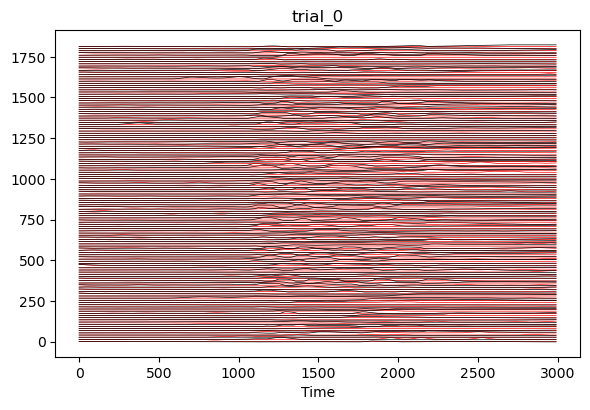

In [73]:
trial_plot = 0
plotTraj(dset_samples[trial_plot], data_sim = traj_sim_tau1[trial_plot], title = 'trial_' + str(trial_plot))

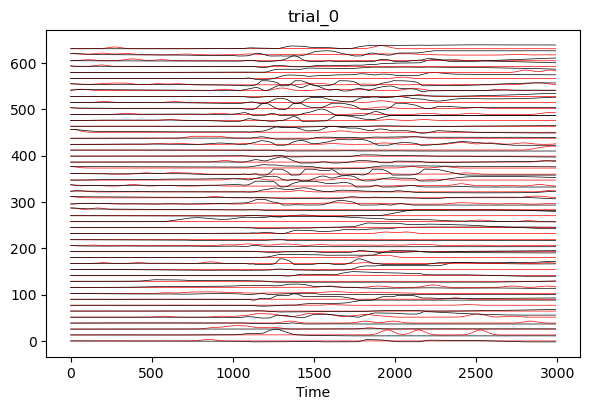

In [74]:
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau1[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### latnet space (tau = 0.0)

In [75]:
traj_sim_tau0, _ = generate_traj_cov(dyn_net.to(device), dset_samples,
                                     n_step = T_max, tau = 0.0,
                                     lag_samples = lag_samples,
                                     device = device, lag = lag,
                                     include_x0_tau = False,
                                     covStat_samples = covStat_samples,
                                     oracle = False, lag_cov_list_pre = lag_cov_list,
                                     flow_net = flow_net.to(device), clamp_range = clamp_range)

project starting points to latent


100%|███████████████████████████████████████| 3701/3701 [02:50<00:00, 21.70it/s]


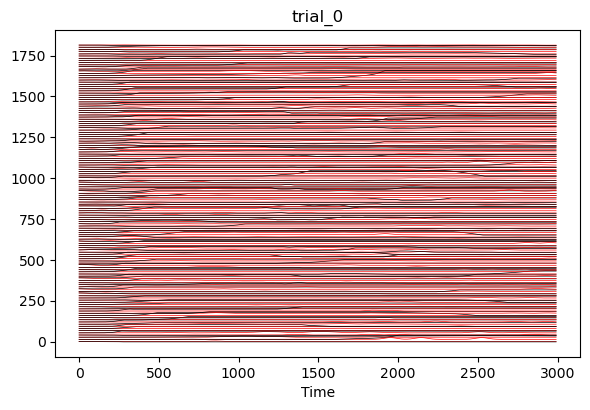

In [76]:
trial_plot = 0
plotTraj(dset_samples[trial_plot], data_sim = traj_sim_tau0[trial_plot], title = 'trial_' + str(trial_plot))

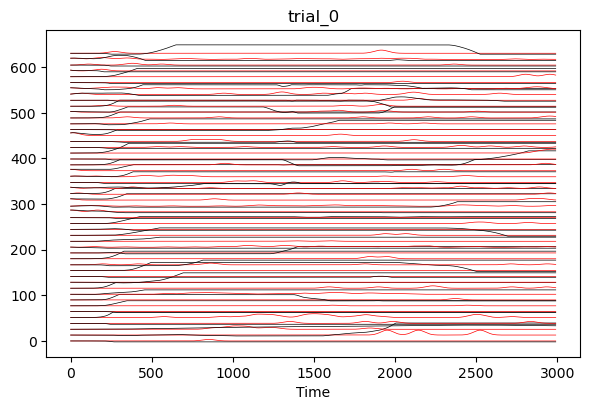

In [77]:
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau0[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

## 3.3 Latent trajectories

### 3.3.1 simulated latent trajectories

In [78]:
mu_traj = latent_mu(traj_sim_tau0, encoder, dim_preserve, device)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 1626.35it/s]


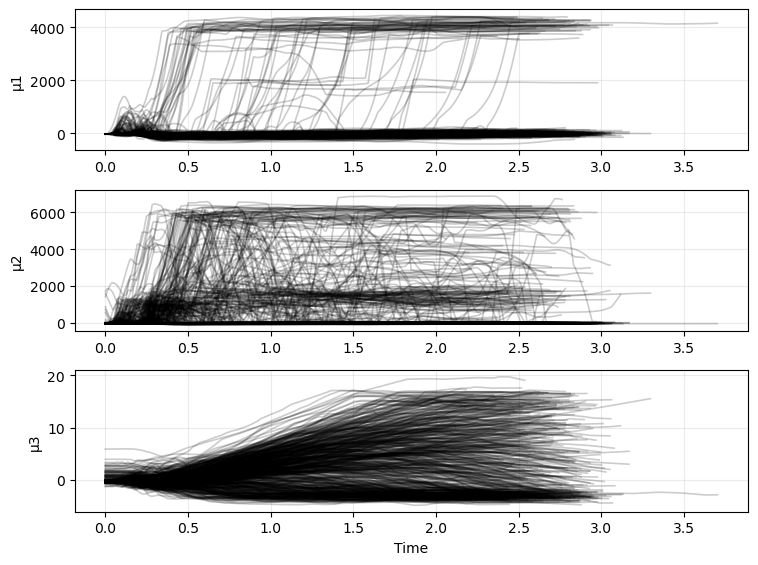

In [79]:
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)

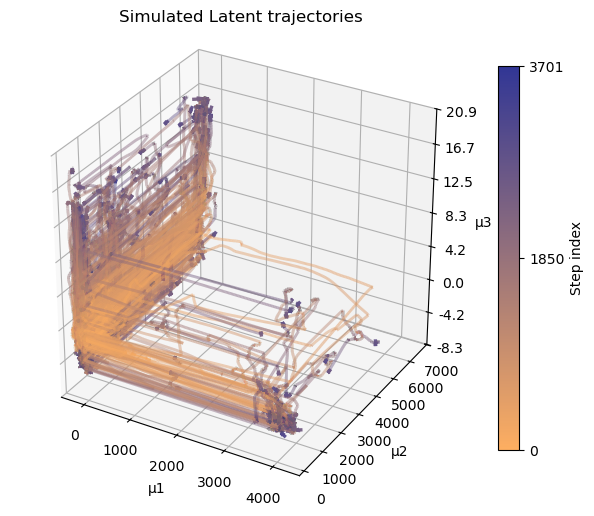

In [80]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)

### 3.3.2 Flow data to latent space

In [81]:
latent_traj_list = proj_to_latent(dset_samples, flow_net, 0.0, device)

100%|█████████████████████████████████████████| 592/592 [00:09<00:00, 61.32it/s]


100%|███████████████████████████████████████| 592/592 [00:00<00:00, 1637.67it/s]


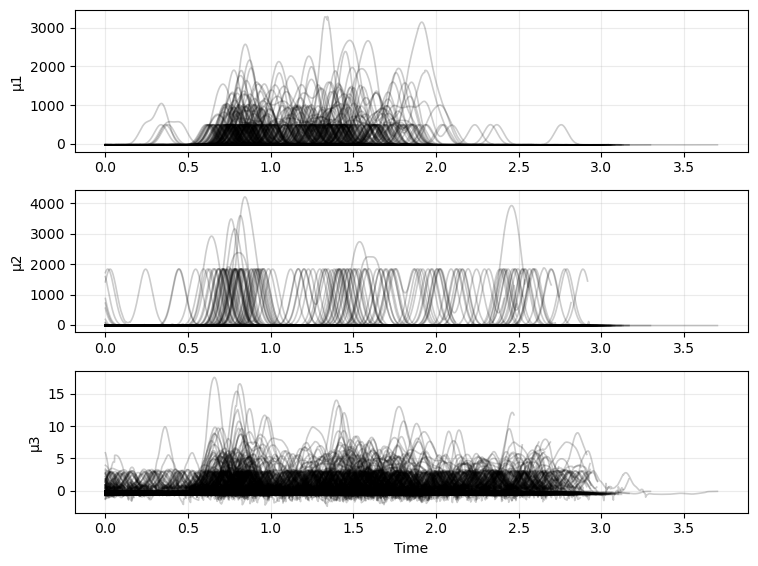

In [82]:
mu_traj = latent_mu(latent_traj_list, encoder, dim_preserve, device)
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)

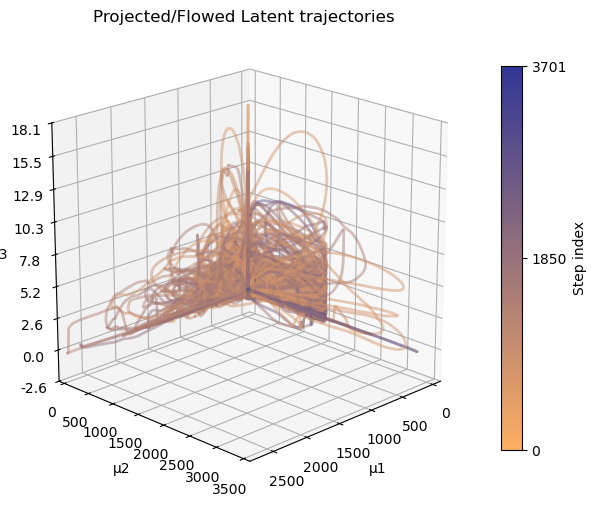

In [31]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, trial_indices=np.arange(len(mu_traj_np)), dims=(0,1,2),
    title="Projected/Flowed Latent trajectories",
    elev_azim = (20, 45),
)

# 4. Another Run...

In [85]:
folder = 'out/z_scored/maze/dim3_lag5_v2/00003-maze_dim3_lag5-prr-uncond-regularFM-gpus1-batch256-fp32'
pkl_path = folder + '/network-snapshot-612147.pkl'

In [86]:
with open(pkl_path, 'rb') as f:
    model_all = pickle.load(f)
if 'ema' in model_all: net = model_all['ema']  # EMA-stabilized model (recommended for inference/simulation)
else: net = model_all['net']  # Raw trained model
flow_net = net.unet_model  # Compressive flow (u_theta)
dyn_net = net.vnet_model   # Dynamics flow (v_theta)
encoder = net.encoder      # For latent proposals

## 4.1 genearted trajectories

### data space (tau = 1.0)

In [87]:
traj_sim_tau1, lag_cov_list = generate_traj_cov(dyn_net.to(device), dset_samples,
                                                n_step = T_max, tau = 1.0,
                                                lag_samples = lag_samples,
                                                device = device, lag = lag,
                                                include_x0_tau = False,
                                                covStat_samples = covStat_samples,
                                                oracle = False, lag_cov_list_pre = None,
                                                clamp_range = clamp_range)

100%|███████████████████████████████████████| 3701/3701 [02:44<00:00, 22.48it/s]


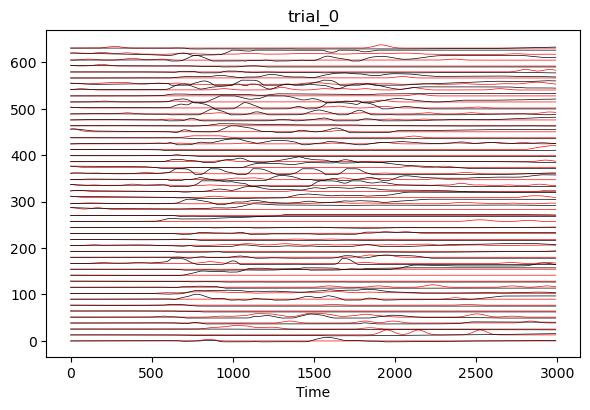

In [88]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau1[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### latent space (tau = 0.0)

In [89]:
traj_sim_tau0, _ = generate_traj_cov(dyn_net.to(device), dset_samples,
                                     n_step = T_max, tau = 0.0,
                                     lag_samples = lag_samples,
                                     device = device, lag = lag,
                                     include_x0_tau = False,
                                     covStat_samples = covStat_samples,
                                     oracle = False, lag_cov_list_pre = lag_cov_list,
                                     flow_net = flow_net.to(device), clamp_range = clamp_range)

project starting points to latent


100%|███████████████████████████████████████| 3701/3701 [02:50<00:00, 21.68it/s]


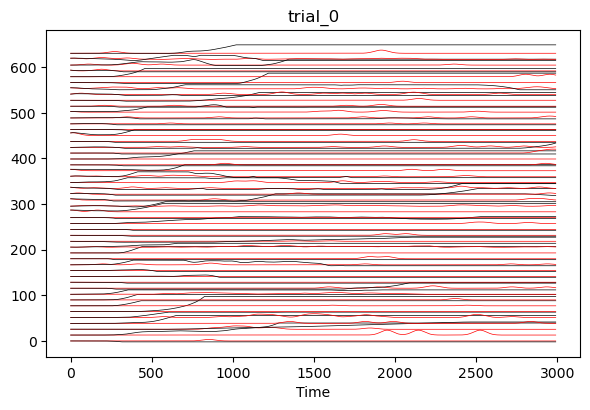

In [90]:
trial_plot = 0
neuron_s = 0
neuron_e = 50
plotTraj(dset_samples[trial_plot][:,neuron_s:neuron_e],
         data_sim = traj_sim_tau0[trial_plot][:,neuron_s:neuron_e], title = 'trial_' + str(trial_plot))

### 3.3 latent trajectories

### 3.3.1 simulated latent trajectories

In [96]:
mu_traj = latent_mu(traj_sim_tau0, encoder, dim_preserve, device)

100%|███████████████████████████████████████| 592/592 [00:00<00:00, 1627.74it/s]


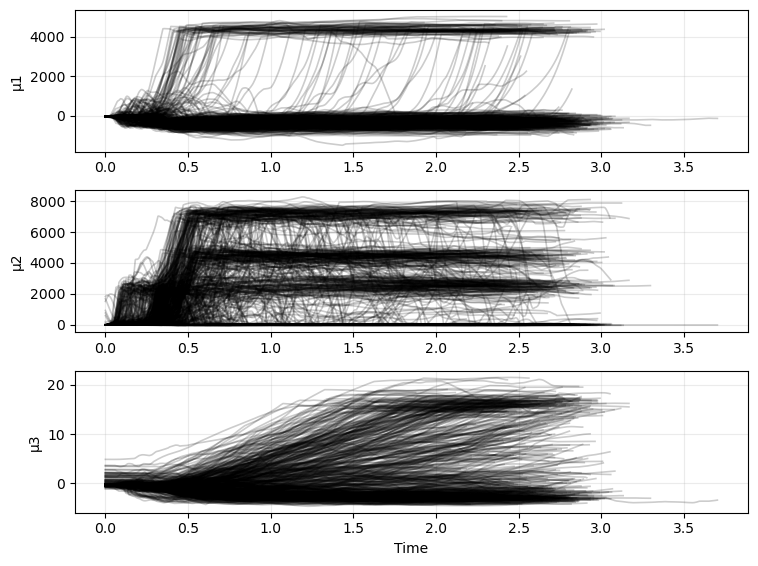

In [97]:
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)

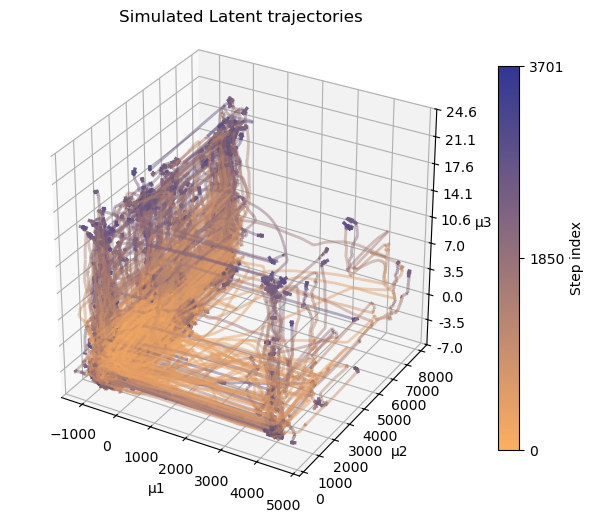

In [98]:
plot_mu_trajectories_gradient_steps_3d(
    mu_traj_np, 
    trial_indices=np.arange(len(mu_traj_np)), 
    dims=(0,1,2),
    title="Simulated Latent trajectories",
    z_scale='auto',  # Automatically scales z to be visually comparable to x and y
    aspect_ratio=(1, 1, 1),
    elev_azim = None, # (20,45)
)

### 3.3.2 flow data to latent trajectories

In [94]:
latent_traj_list = proj_to_latent(dset_samples, flow_net, 0.0, device)

100%|█████████████████████████████████████████| 592/592 [00:09<00:00, 62.84it/s]


100%|███████████████████████████████████████| 592/592 [00:00<00:00, 1669.05it/s]


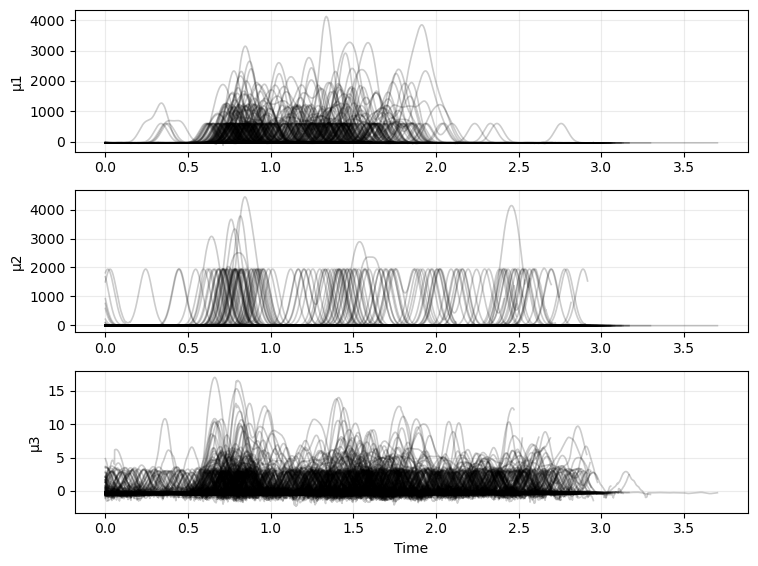

In [95]:
mu_traj = latent_mu(latent_traj_list, encoder, dim_preserve, device)
mu_traj_np = [mu_traj[j].cpu().numpy() for j in range(len(mu_traj))]
plot_latent_time_series(mu_traj_np, alpha = 0.2, dims=np.arange(dim_preserve),
                        dt=dt, labels=None)